# Model selection 
Select the predicitons tools, scores and settings that best can predicit anti-drug antibodies (ADA) for 218 antibodies.\
Computation of the scores are made in the script "compute_scores" and then imported directly


In [32]:
# load libaries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm 

In [34]:
# Load table with all computed scores for all tools
computed_scors_biophi = pd.read_csv("all_predictors_217AB(biophidata).csv")
computed_scors_biophi = computed_scors_biophi.drop(columns=['Unnamed: 0'])
computed_scors_biophi.head()   

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.298103,94.751924,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,8.465608,95.632836,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,8.024691,96.265295,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.760141,99.620457,8.581752,96.304780,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.583774,96.624264,0.095804,31.544048,39,0.924883,0.835681


# Scatterplot ADA against all 15 predictors

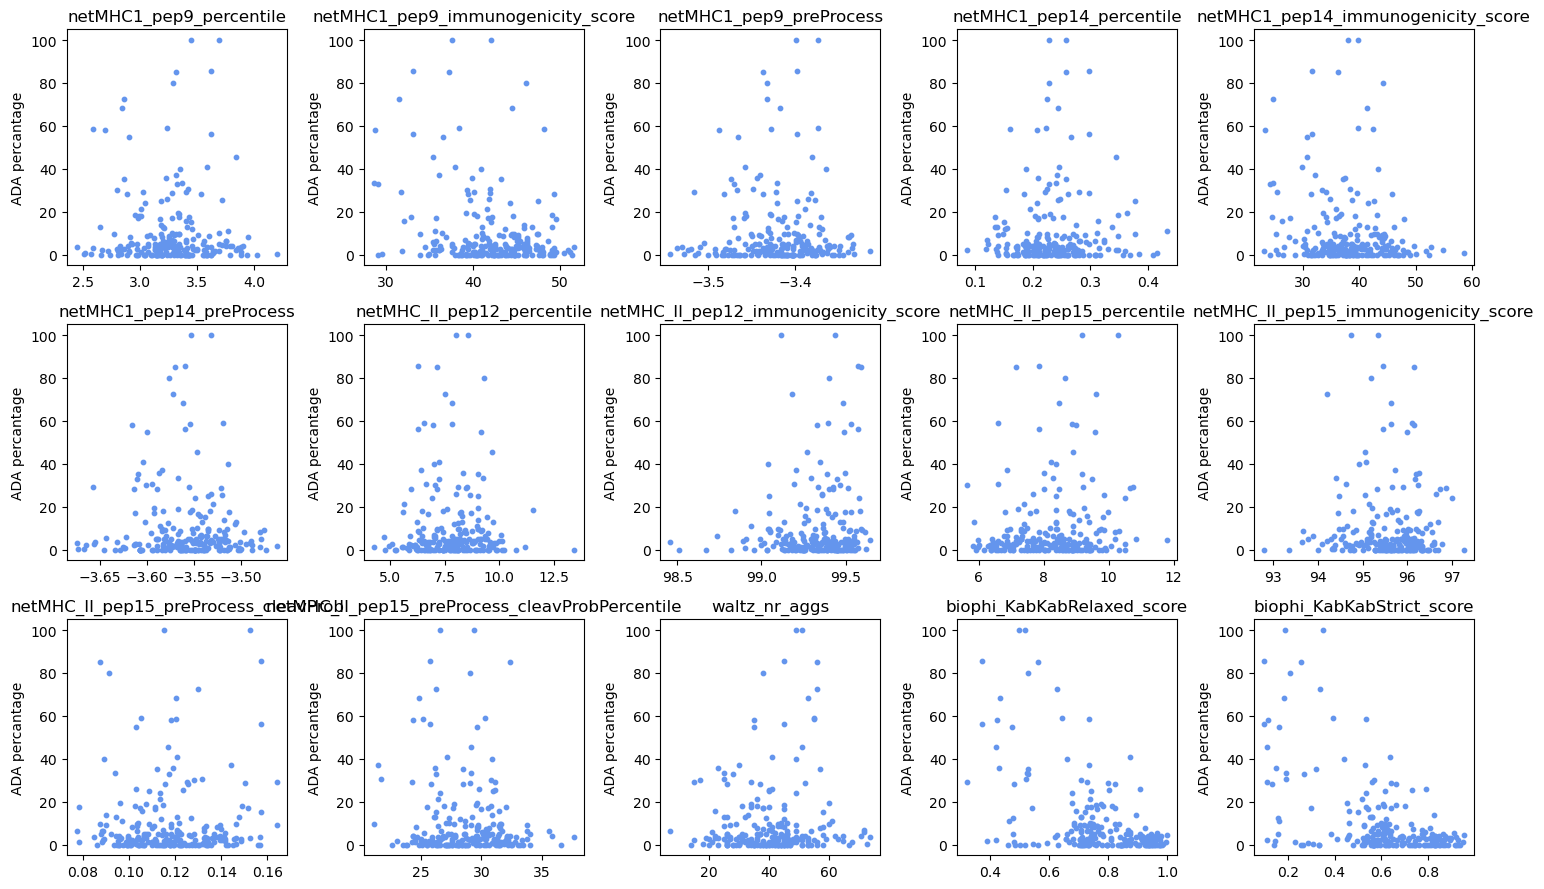

In [35]:
# for loop for all columns, make a scatter plot for each predictor against ADA

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(2, 17):
    ax = axes[i - 2]
    
    y = computed_scors_biophi['ADA_percentage']
    x = computed_scors_biophi.iloc[:, i]
    
    ax.scatter(x, y, s=10, c="cornflowerblue")
    ax.set_title(computed_scors_biophi.columns[i])
    ax.set_ylabel('ADA percantage')

plt.tight_layout()
plt.show()

# Correlation matrix

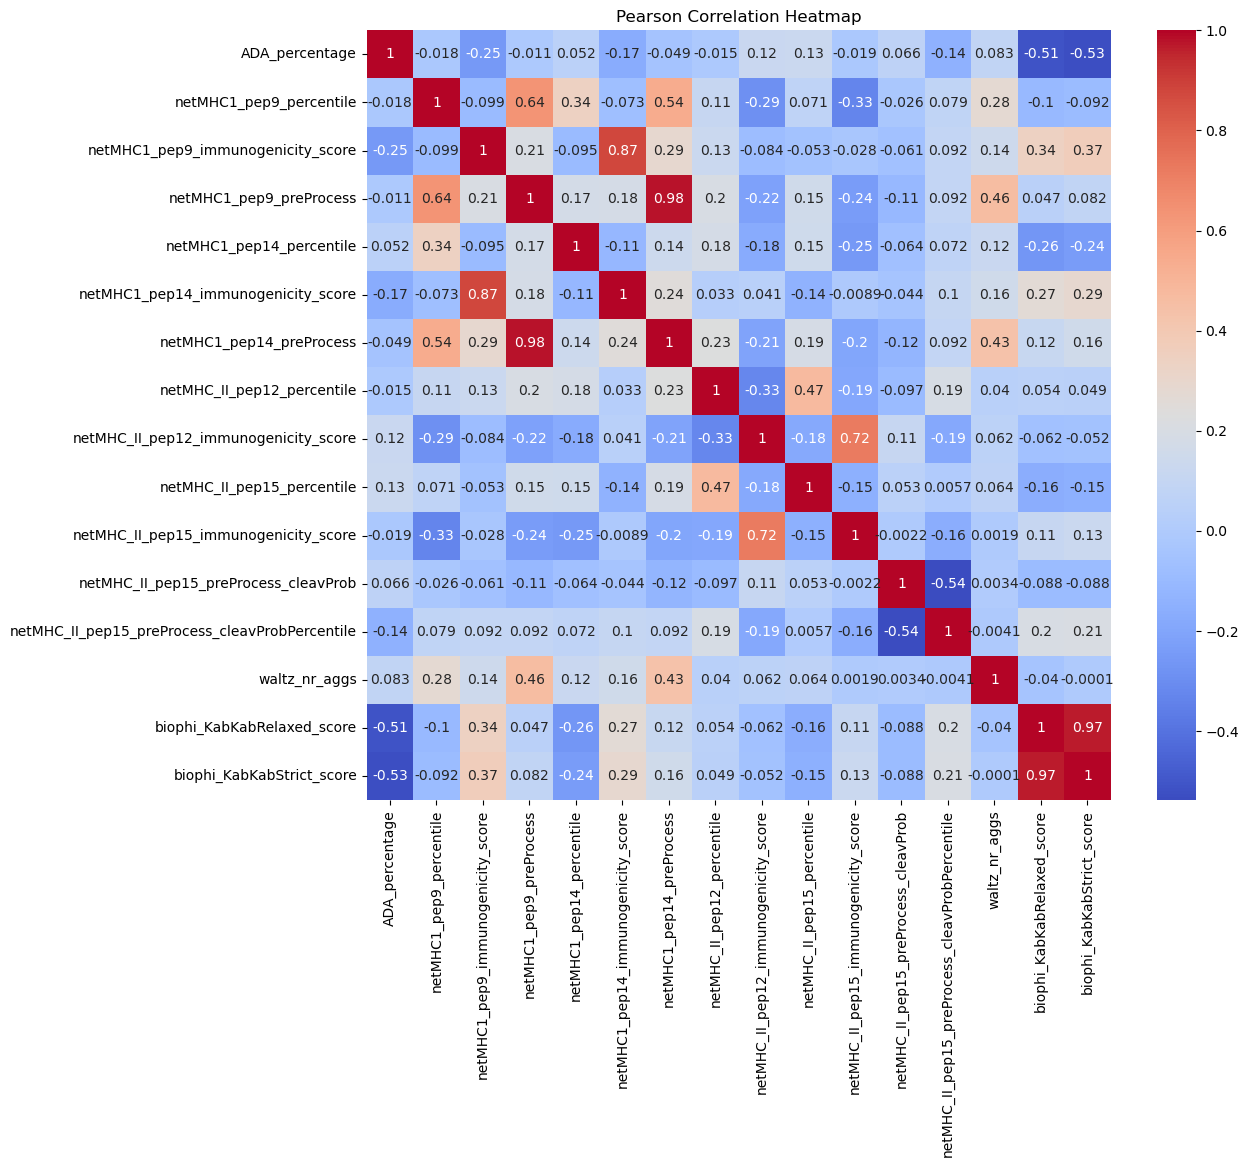

In [36]:
# First create a df without the antibody name and ADA percantage
ADA_corrtest = computed_scors_biophi.drop(columns=['antibody'])
pearson_corr = ADA_corrtest.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

In [37]:
# print the correlation of the ADA percentage column
pearson_corr['ADA_percentage'].sort_values(ascending=False)

ADA_percentage                                    1.000000
netMHC_II_pep15_percentile                        0.128810
netMHC_II_pep12_immunogenicity_score              0.119333
waltz_nr_aggs                                     0.083257
netMHC_II_pep15_preProcess_cleavProb              0.065528
netMHC1_pep14_percentile                          0.051819
netMHC1_pep9_preProcess                          -0.010767
netMHC_II_pep12_percentile                       -0.014772
netMHC1_pep9_percentile                          -0.017923
netMHC_II_pep15_immunogenicity_score             -0.018824
netMHC1_pep14_preProcess                         -0.048743
netMHC_II_pep15_preProcess_cleavProbPercentile   -0.142347
netMHC1_pep14_immunogenicity_score               -0.167915
netMHC1_pep9_immunogenicity_score                -0.253633
biophi_KabKabRelaxed_score                       -0.508176
biophi_KabKabStrict_score                        -0.528191
Name: ADA_percentage, dtype: float64

# Lasso regression

In [38]:
computed_scors_biophi

,antibody,ADA_percentage,netMHC1_pep9_percentile,netMHC1_pep9_immunogenicity_score,netMHC1_pep9_preProcess,netMHC1_pep14_percentile,netMHC1_pep14_immunogenicity_score,netMHC1_pep14_preProcess,netMHC_II_pep12_percentile,netMHC_II_pep12_immunogenicity_score,netMHC_II_pep15_percentile,netMHC_II_pep15_immunogenicity_score,netMHC_II_pep15_preProcess_cleavProb,netMHC_II_pep15_preProcess_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.0,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.298103,94.751924,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.1,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,8.465608,95.632836,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.5,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,8.024691,96.265295,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.4,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.760141,99.620457,8.581752,96.304780,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.0,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.583774,96.624264,0.095804,31.544048,39,0.924883,0.835681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,zalutumumab,0.0,3.191138,42.410714,-3.394748,0.219855,38.356164,-3.521994,6.584362,99.248820,7.665805,95.634202,0.117738,25.100465,42,0.930556,0.805556
214,zolbetuximab,0.0,3.039362,39.461883,-3.458596,0.220863,36.238532,-3.593007,6.804479,99.524084,9.302326,96.309374,0.111857,27.603953,44,0.562791,0.334884
215,zolimomab,85.7,3.618365,33.179724,-3.398370,0.296995,31.603774,-3.558859,6.287683,99.571700,7.859079,95.456749,0.157254,25.740732,45,0.373206,0.095694
216,moab_81c6,100.0,3.686945,42.081448,-3.399031,0.257202,39.814815,-3.552895,8.585859,99.434207,9.171076,95.339264,0.152478,26.621190,49,0.516432,0.352113


In [39]:
# Create feature variables
X = computed_scors_biophi.drop(columns=['antibody', 'ADA_percentage']) # all except the response variable and the antibody names
y = computed_scors_biophi['ADA_percentage'] # the response varibale

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5,max_iter=10000)  # cross-validation
)

model.fit(X, y)

# coefficients
coef = model.named_steps['lassocv'].coef_

selected_features = X.columns[coef != 0]

# print the features that Lasso "decided" are the best once to use for the prediction
selected_features

Index(['netMHC1_pep9_immunogenicity_score',
       'netMHC_II_pep12_immunogenicity_score', 'waltz_nr_aggs',
       'biophi_KabKabStrict_score'],
      dtype='object')

# Manual building models
This is to also look at other combinations that what Lasso generated and check how much they influence the results. Models with biology in mind for example.

In [ ]:
# print all column names, to get an overview of what potetnial predictors can be used 
X.iloc[1]

In [ ]:
# model 1
# The two features considred best my Lasso
model1 = sm.ols(formula= 'ADA_percentage ~ netMHC_II_pep12_percentile + netMHC_II_pep15_immunogenicity_score', 
                data=all_predictors_andADA).fit()

# Compute and print model fit calculations
print('AIC, R^2, adjusted R^2')
print("Model1:", model1.aic, model1.rsquared, model1.rsquared_adj)

# Visualization of results